# CSE445 Group 1
## Animal Image Classification Pipeline



In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow & VGG16 for Feature Extraction
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

# Scikit-Learn Models & XGBoost
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# --- GPU check ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU(s) detected: {[gpu.name for gpu in gpus]}")
    # Optional: allow memory growth to avoid TF grabbing all VRAM at once
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as e:
            print(e)
else:
    print("No GPU detected by TensorFlow. Check your CUDA/cuDNN + tensorflow-gpu install.")

GPU(s) detected: ['/physical_device:GPU:0']


In [2]:
import os
import shutil
import tensorflow as tf

BASE_DIR = r"F:\CSE445 Project\data"
VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.gif', '.bmp')
QUARANTINE_DIR = os.path.join(BASE_DIR, "_bad_files")

def scan_and_quarantine(base_dir, move_bad_files=False):
    bad_files = []
    for root, _, files in os.walk(base_dir):
        # Skip the quarantine folder itself on repeat runs
        if os.path.normpath(root).startswith(os.path.normpath(QUARANTINE_DIR)):
            continue
        for fname in files:
            fpath = os.path.join(root, fname)

            # 1. Flag files with an extension Keras doesn't accept
            if not fname.lower().endswith(VALID_EXTENSIONS):
                bad_files.append((fpath, "unsupported extension"))
                continue

            # 2. Flag files whose CONTENT isn't actually a decodable image
            #    (this catches mislabeled extensions and truncated/corrupt files)
            try:
                raw = tf.io.read_file(fpath)
                tf.io.decode_image(raw)
            except Exception as e:
                bad_files.append((fpath, f"failed to decode: {e}"))

    print(f"Scan complete. Found {len(bad_files)} problematic file(s).\n")
    for fpath, reason in bad_files:
        print(f" - {fpath}\n     reason: {reason}")

    if move_bad_files and bad_files:
        os.makedirs(QUARANTINE_DIR, exist_ok=True)
        for fpath, _ in bad_files:
            dest = os.path.join(QUARANTINE_DIR, os.path.basename(fpath))
            shutil.move(fpath, dest)
        print(f"\nMoved {len(bad_files)} file(s) to {QUARANTINE_DIR}")

    return bad_files

# First pass: just report, don't move anything yet
bad_files_found = scan_and_quarantine(BASE_DIR, move_bad_files=True)

# Once you've reviewed the list above, rerun this line with move_bad_files=True to
# automatically move the bad files out of train/val/test so they can't break loading:
# bad_files_found = scan_and_quarantine(BASE_DIR, move_bad_files=True)

Scan complete. Found 0 problematic file(s).



In [3]:
import os
from tensorflow.keras.utils import image_dataset_from_directory
import numpy as np

# Local dataset path (Windows path, using raw string to avoid escape issues)
BASE_DIR = r"F:\CSE445 Project\data"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Function to load dataset without shuffling so labels align perfectly for Scikit-Learn
def load_data(folder_name):
    dir_path = os.path.join(BASE_DIR, folder_name)
    return image_dataset_from_directory(
        dir_path,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

print("Loading datasets from local disk ...")
train_ds = load_data('train')
val_ds = load_data('val')
test_ds = load_data('test')

# Extract exact integer labels to use for Scikit-Learn training
y_train = np.concatenate([y for x, y in train_ds], axis=0)
y_val = np.concatenate([y for x, y in val_ds], axis=0)
y_test = np.concatenate([y for x, y in test_ds], axis=0)

# Get class names for later
class_names = train_ds.class_names
print(f"Classes found: {class_names}")

Loading datasets from local disk ...
Found 347 files belonging to 5 classes.
Found 75 files belonging to 5 classes.
Found 75 files belonging to 5 classes.
Classes found: ['cat', 'cow', 'dog', 'lamb', 'zebra']


In [4]:
# Load VGG16 without the final classification layer (include_top=False)
# pooling='avg' flattens the output into a neat 512-dimensional vector per image.
vgg_feature_extractor = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3), pooling='avg')

def extract_features(dataset):
    features = []
    for images, labels in dataset:
        # Preprocess images to match VGG16's specific formatting requirements
        preprocessed_images = preprocess_input(images)
        # Extract features
        extracted = vgg_feature_extractor.predict(preprocessed_images, verbose=0)
        features.append(extracted)
    return np.vstack(features)

print("Extracting features from Train set...")
X_train = extract_features(train_ds)

print("Extracting features from Validation set...")
X_val = extract_features(val_ds)

print("Extracting features from Test set...")
X_test = extract_features(test_ds)

print(f"Feature extraction complete! Training features shape: {X_train.shape}")

Extracting features from Train set...
Extracting features from Validation set...
Extracting features from Test set...
Feature extraction complete! Training features shape: (347, 512)


## K-Nearest Neighbors (KNN) Classification


Tuning KNN hyperparameters with GridSearchCV...
Fitting 5 folds for each of 42 candidates, totalling 210 fits
Best hyperparameters: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}
Best cross-validated training accuracy: 89.62%

Validation Accuracy: 92.00%

KNN finished. Test Accuracy: 93.33%

--- Classification Report ---
              precision    recall  f1-score   support

         cat       1.00      0.80      0.89        15
         cow       0.94      1.00      0.97        15
         dog       1.00      0.93      0.97        15
        lamb       0.83      1.00      0.91        15
       zebra       0.93      0.93      0.93        15

    accuracy                           0.93        75
   macro avg       0.94      0.93      0.93        75
weighted avg       0.94      0.93      0.93        75



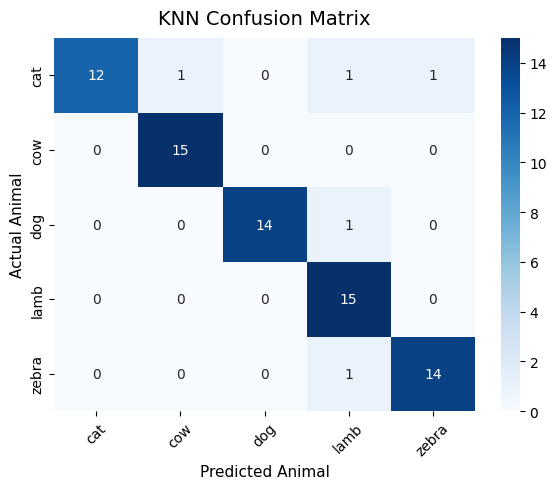

Calculating Learning Curve... (This might take a few seconds)


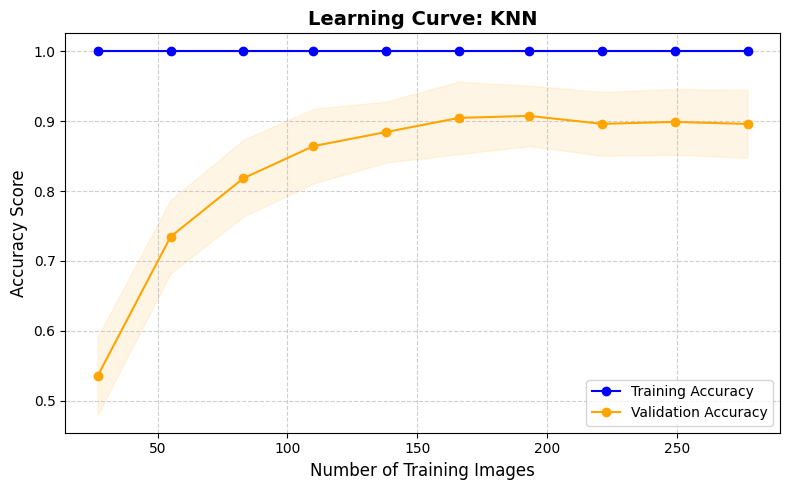

In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, learning_curve
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Feature Scaling ---
# KNN relies on distance calculations, so it is just as sensitive to feature
# magnitude as SVM. We reuse the same standardization approach: fit the
# scaler ONLY on the training set to avoid leaking test/val statistics.
scaler_knn = StandardScaler()
X_train_scaled_knn = scaler_knn.fit_transform(X_train)
X_val_scaled_knn = scaler_knn.transform(X_val)
X_test_scaled_knn = scaler_knn.transform(X_test)

# --- Hyperparameter Tuning ---
# Grid search over k (n_neighbors), the weighting scheme, and the distance
# metric using 5-fold CV on the training set, so we don't just rely on
# KNeighborsClassifier's default hyperparameters.
print("Tuning KNN hyperparameters with GridSearchCV...")
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}
grid_search_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    n_jobs=-1,
    scoring='accuracy',
    verbose=1
)
grid_search_knn.fit(X_train_scaled_knn, y_train)

print(f"Best hyperparameters: {grid_search_knn.best_params_}")
print(f"Best cross-validated training accuracy: {grid_search_knn.best_score_ * 100:.2f}%")

knn_model = grid_search_knn.best_estimator_

# --- Validation Check ---
# Quick sanity check on the held-out validation set before we touch the test set.
y_val_pred_knn = knn_model.predict(X_val_scaled_knn)
val_acc_knn = accuracy_score(y_val, y_val_pred_knn)
print(f"\nValidation Accuracy: {val_acc_knn * 100:.2f}%")

# --- Final Test Evaluation ---
y_pred_knn = knn_model.predict(X_test_scaled_knn)
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"\nKNN finished. Test Accuracy: {acc_knn * 100:.2f}%\n")

# --- 1. Classification Report ---
print("--- Classification Report ---")
print(classification_report(y_test, y_pred_knn, target_names=class_names))

# --- 2. Confusion Matrix ---
plt.figure(figsize=(6, 5))
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('KNN Confusion Matrix', fontsize=14, pad=10)
plt.ylabel('Actual Animal', fontsize=11)
plt.xlabel('Predicted Animal', fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- 3. Learning Curve ---
print("Calculating Learning Curve... (This might take a few seconds)")
np.random.seed(42)
shuffle_indices_knn = np.random.permutation(len(X_train_scaled_knn))
X_train_shuffled_knn = X_train_scaled_knn[shuffle_indices_knn]
y_train_shuffled_knn = y_train[shuffle_indices_knn]

train_sizes_knn, train_scores_knn, test_scores_knn = learning_curve(
    knn_model, X_train_shuffled_knn, y_train_shuffled_knn,
    cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy'
)

train_mean_knn = np.mean(train_scores_knn, axis=1)
train_std_knn = np.std(train_scores_knn, axis=1)
test_mean_knn = np.mean(test_scores_knn, axis=1)
test_std_knn = np.std(test_scores_knn, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes_knn, train_mean_knn, 'o-', color="blue", label="Training Accuracy")
plt.plot(train_sizes_knn, test_mean_knn, 'o-', color="orange", label="Validation Accuracy")
plt.fill_between(train_sizes_knn, train_mean_knn - train_std_knn, train_mean_knn + train_std_knn, alpha=0.1, color="blue")
plt.fill_between(train_sizes_knn, test_mean_knn - test_std_knn, test_mean_knn + test_std_knn, alpha=0.1, color="orange")
plt.title("Learning Curve: KNN", fontsize=14, fontweight='bold')
plt.xlabel("Number of Training Images", fontsize=12)
plt.ylabel("Accuracy Score", fontsize=12)
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
